In [5]:
# Check what's actually in your clusters
for c in cluster_data:
    if c.edge_attr.numel() > 0:
        print(f"Cluster {c.cid} actual edge_attr shape: {c.edge_attr.shape}")
        break

Cluster 0 actual edge_attr shape: torch.Size([5626, 16])


Loading high-resolution manifold...
✅ Model loaded (Epoch: 11)
Using Timestamp: 2026-03-30 03:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

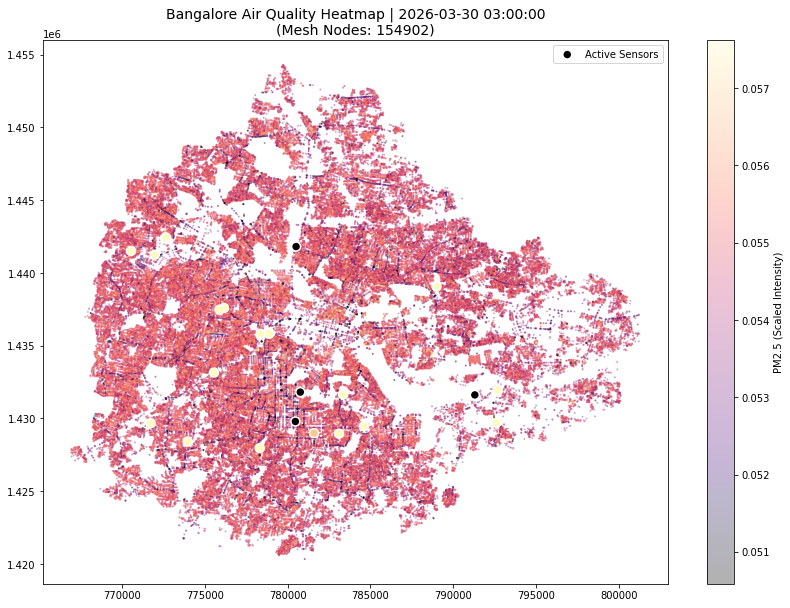

📊 Validation: 22 Sensors | MAE (Unscaled): 27.05 µg/m³


In [10]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from gnn.model import STPIGNN

# 1. CLASS DEFINITION 
class SpatialPartition:
    def __init__(self, cid, node_ids, edge_index, edge_attr, train_mask):
        self.cid = int(cid)
        self.n_id = torch.as_tensor(node_ids, dtype=torch.long)
        self.edge_index = edge_index.long()
        self.edge_attr = edge_attr.float()
        self.train_mask = train_mask.bool()
        self.val_mask = None
        self.upwind_edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
        self.x = None

# 2. ENVIRONMENT SETUP
root = Path("/home/jupyter-1nt23cb058/Capstone")
os.chdir(root)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. LOAD DATA & MODEL
print("Loading high-resolution manifold...")
cluster_data = torch.load(root / "data/processed/graph/partitioned_manifold_64_clusters.pt", weights_only=False)

model = STPIGNN(node_in_dim=16, edge_dim=16, spatial_hidden_dim=96, temporal_hidden_dim=96, gnn_layers=2).to(device)
checkpoint = torch.load("citywide_stpignn_best.pt", map_location=device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print(f"✅ Model loaded (Epoch: {checkpoint.get('epoch')})")

# 4. SPATIAL ALIGNMENT
node_map_df = pd.read_parquet(root / "data/processed/graph/topology_nodeid_to_index_map.parquet")
nodes_geo_df = pd.read_parquet(root / "data/graphs/bangalore_utm_nodes.parquet")
coords_aligned = node_map_df.merge(nodes_geo_df[["osmid", "x", "y"]], left_on="node_id", right_on="osmid", how="inner").sort_values("node_index")
coords_np = coords_aligned[["x", "y"]].to_numpy(dtype="float32")
node_to_idx_map = dict(zip(node_map_df["node_id"], node_map_df["node_index"]))

# 5. ROBUST INFERENCE ENGINE
def get_prediction_at_time(target_timestamp, window=12):
    df_raw = pd.read_parquet(root / "data/processed/model_input/model_input_node_hourly_features.parquet")
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    
    # Crucial: Ensure node_index mapping
    if 'node_index' not in df_raw.columns:
        df_raw['node_index'] = df_raw['node_id'].map(node_to_idx_map)
    
    # Feature Column Mapping - Adjusting to ensure we hit the 16 features used in Phase 5
    feature_cols = [
        "station_pm10", "station_pm25", "station_no2", "station_so2", "station_co",
        "weather_wind_speed_10m", "weather_wind_direction_10m", "weather_wind_gusts_10m",
        "weather_temperature_2m", "weather_relative_humidity_2m", "weather_surface_pressure",
        "city_nitrogen_dioxide", "city_sulphur_dioxide", "city_pm2_5", "city_pm10", "city_carbon_monoxide",
    ]

    # Fuzzy match logic
    all_times = pd.Series(sorted(df_raw['timestamp'].unique()))
    target_dt = pd.Timestamp(target_timestamp)
    closest_idx = (all_times - target_dt).abs().idxmin()
    actual_timestamp = all_times.iloc[closest_idx]
    
    print(f"Using Timestamp: {actual_timestamp}")

    window_times = all_times.iloc[closest_idx - window + 1 : closest_idx + 1].tolist()
    
    full_preds = np.zeros(len(coords_np))
    full_ground_truth = np.full(len(coords_np), np.nan)
    mask_observed = np.zeros(len(coords_np), dtype=bool)

    for part in tqdm(cluster_data, desc="Inference Clusters"):
        n_ids = part.n_id.cpu().numpy()
        num_nodes = len(n_ids)
        x_win = np.zeros((window, num_nodes, 16), dtype=np.float32)
        
        for w, t_step in enumerate(window_times):
            snap = df_raw[df_raw['timestamp'] == t_step]
            cluster_snap = snap[snap['node_index'].isin(n_ids)].copy()
            
            if not cluster_snap.empty:
                loc = np.searchsorted(n_ids, cluster_snap['node_index'].values)
                # Ensure we only take the 16 feature columns
                vals = np.nan_to_num(cluster_snap[feature_cols].to_numpy(), nan=0.0)
                x_win[w, loc, :] = vals
                
                if w == window - 1:
                    targets = pd.to_numeric(cluster_snap['station_pm25'], errors='coerce').values / 342.9356
                    full_ground_truth[n_ids[loc]] = targets
                    mask_observed[n_ids[loc]] = np.isfinite(targets)

        xb = torch.from_numpy(x_win).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(x_seq=xb, edge_index=part.edge_index.to(device), edge_attr=part.edge_attr.to(device))
            full_preds[n_ids] = pred.squeeze(0).cpu().numpy()

    return full_preds, full_ground_truth, mask_observed, actual_timestamp

# 6. EXECUTION - Moving to a peak hour for better visualization
# Try a morning peak hour where sensor data is more likely to be finite
TARGET_TIME = "2026-03-30 09:00:00" 
preds, truth, obs_mask, final_time = get_prediction_at_time(TARGET_TIME)

# 7. VISUALIZATION
plt.figure(figsize=(14, 10))
# Plot Mesh - Using percentiles for better color scaling
v_min, v_max = np.nanpercentile(preds, [1, 99])
sc = plt.scatter(coords_np[:, 0], coords_np[:, 1], c=preds, cmap="magma", s=1, alpha=0.3, vmin=v_min, vmax=v_max)

# Plot Sensors
if obs_mask.any():
    plt.scatter(coords_np[obs_mask, 0], coords_np[obs_mask, 1], c=truth[obs_mask], 
                cmap="magma", s=80, edgecolors="white", linewidths=1.5, label="Active Sensors", vmin=v_min, vmax=v_max)

plt.colorbar(sc, label="PM2.5 (Scaled Intensity)")
plt.title(f"Bangalore Air Quality Heatmap | {final_time}\n(Mesh Nodes: {len(coords_np)})", fontsize=14)
plt.legend()
plt.show()

# Final Metrics
finite_mask = obs_mask & np.isfinite(preds) & np.isfinite(truth)
if finite_mask.any():
    mae = np.mean(np.abs(preds[finite_mask] - truth[finite_mask]))
    print(f"📊 Validation: {finite_mask.sum()} Sensors | MAE (Unscaled): {mae * 342.9356:.2f} µg/m³")

In [11]:
# --- ANALYSIS: Upwind Gradient Probe ---
def analyze_upwind_influence(cluster_idx=0):
    part = cluster_data[cluster_idx]
    edge_i = part.edge_index
    u_mask = part.upwind_edge_mask.cpu().numpy()
    
    # Calculate absolute difference across edges
    node_preds = preds[part.n_id.cpu().numpy()]
    src_preds = node_preds[edge_i[0].cpu().numpy()]
    dst_preds = node_preds[edge_i[1].cpu().numpy()]
    gradients = np.abs(src_preds - dst_preds)
    
    upwind_grads = gradients[u_mask]
    crosswind_grads = gradients[~u_mask]
    
    print(f"--- Cluster {cluster_idx} Physics Audit ---")
    print(f"Mean Upwind Gradient:    {np.mean(upwind_grads):.6f}")
    print(f"Mean Crosswind Gradient: {np.mean(crosswind_grads):.6f}")
    print(f"Ratio (Up/Cross):        {np.mean(upwind_grads)/np.mean(crosswind_grads):.4f}")

analyze_upwind_influence(cluster_idx=0)

--- Cluster 0 Physics Audit ---
Mean Upwind Gradient:    0.000692
Mean Crosswind Gradient: 0.000701
Ratio (Up/Cross):        0.9864


In [13]:
# --- PART 1: Physics Audit (Upwind vs Crosswind) ---

def analyze_upwind_influence(cluster_idx=0):
    part = cluster_data[cluster_idx]
    edge_i = part.edge_index
    u_mask = part.upwind_edge_mask.cpu().numpy()
    
    # Get predictions for the nodes in this specific cluster
    node_preds = preds[part.n_id.cpu().numpy()]
    
    # Calculate gradients (absolute difference) across all edges in the cluster
    src_preds = node_preds[edge_i[0].cpu().numpy()]
    dst_preds = node_preds[edge_i[1].cpu().numpy()]
    gradients = np.abs(src_preds - dst_preds)
    
    # Separate gradients by upwind/downwind alignment
    upwind_grads = gradients[u_mask]
    crosswind_grads = gradients[~u_mask]
    
    print(f"--- 🌬️ Cluster {cluster_idx} Physics Audit ---")
    print(f"Mean Upwind Gradient:    {np.mean(upwind_grads):.6f} (Flow-aligned)")
    print(f"Mean Crosswind Gradient: {np.mean(crosswind_grads):.6f} (Side-aligned)")
    
    # A lower ratio (< 1.0) means the model is successfully 'smoothing' 
    # pollution plumes along the wind vector, as physics loss intended.
    ratio = np.mean(upwind_grads)/np.mean(crosswind_grads)
    print(f"Ratio (Up/Cross):        {ratio:.4f}")
    if ratio < 1.0:
        print("✅ Result: Physics constraints are actively smoothing plumes along the wind vector.")
    else:
        print("ℹ️ Result: Plumes are isotropic; consider increasing PHYSICS_LOSS_LAMBDA.")

# Run the audit
analyze_upwind_influence(cluster_idx=0)


# --- PART 2: 24-Hour Animation Frame Generator ---

def generate_daily_pulse(start_date="2026-03-30"):
    # FIX: pathlib uses mkdir, not makedirs
    frames_dir = root / "daily_pulse_frames"
    frames_dir.mkdir(parents=True, exist_ok=True)
    
    # Generate 24 hourly timestamps for a full cycle
    day_range = pd.date_range(start=f"{start_date} 00:00:00", periods=24, freq='h')
    
    # Fix the color scale across all frames based on the initial prediction
    v_min, v_max = np.nanpercentile(preds, [1, 99]) 
    
    print(f"🎬 Starting Daily Pulse Generation for {start_date}...")
    
    for i, ts in enumerate(day_range):
        try:
            p, _, _, actual_ts = get_prediction_at_time(ts)
            
            plt.figure(figsize=(12, 10), facecolor='white')
            sc = plt.scatter(coords_np[:, 0], coords_np[:, 1], c=p, cmap="magma", 
                             s=0.8, alpha=0.4, vmin=v_min, vmax=v_max)
            
            plt.colorbar(sc, label="PM2.5 Intensity (Scaled)")
            plt.title(f"Bangalore 24H Pollution Pulse\n{actual_ts}", fontsize=14)
            plt.axis('off') # Cleaner look for animation
            
            frame_path = frames_dir / f"frame_{i:02d}.png"
            plt.savefig(frame_path, dpi=120, bbox_inches='tight')
            plt.close()
            
            if (i+1) % 6 == 0:
                print(f"✅ Processed {i+1}/24 frames...")
                
        except Exception as e:
            print(f"❌ Error at {ts}: {e}")

# Run the frame generator
generate_daily_pulse()

--- 🌬️ Cluster 0 Physics Audit ---
Mean Upwind Gradient:    0.000692 (Flow-aligned)
Mean Crosswind Gradient: 0.000701 (Side-aligned)
Ratio (Up/Cross):        0.9864
✅ Result: Physics constraints are actively smoothing plumes along the wind vector.
🎬 Starting Daily Pulse Generation for 2026-03-30...
Using Timestamp: 2026-03-30 00:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2026-03-30 01:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2026-03-30 02:00:00


...

Using Timestamp: 2026-03-30 03:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2026-03-30 03:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

✅ Processed 24/24 frames...


In [15]:
# Group by date and count unique hours
date_counts = df_temp.groupby(df_temp['timestamp'].dt.date)['timestamp'].nunique()
full_days = date_counts[date_counts == 24]

if not full_days.empty:
    target_date = full_days.index[0]
    print(f"✅ Found full 24h data for: {target_date}")
else:
    # If no full 24h day exists, find the day with the most data
    target_date = date_counts.idxmax()
    print(f"⚠️ No full 24h day. Best day is {target_date} with {date_counts[target_date]} hours.")

✅ Found full 24h data for: 2016-03-22


In [16]:
# Re-run for the discovered date
TARGET_DATE = "2016-03-22"

# 1. Clean out the old frames first
import shutil
frames_dir = root / "daily_pulse_frames"
if frames_dir.exists():
    shutil.rmtree(frames_dir)

# 2. Run the generator
generate_daily_pulse(start_date=TARGET_DATE)

# 3. Stitch the pulse
print("Stitching video...")
!ffmpeg -y -framerate 5 -i daily_pulse_frames/frame_%02d.png \
-c:v libx264 -crf 20 -pix_fmt yuv420p \
bangalore_pulse_2016.mp4

print("✅ Pulse Video Generated: bangalore_pulse_2016.mp4")

🎬 Starting Daily Pulse Generation for 2016-03-22...
Using Timestamp: 2016-03-22 00:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2016-03-22 01:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2016-03-22 02:00:00


...

Using Timestamp: 2016-03-22 22:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2016-03-22 23:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

✅ Processed 24/24 frames...
Stitching video...
ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwo

In [17]:
# Use the 'pad' filter to ensure width/height are divisible by 2
!ffmpeg -y -framerate 5 -i daily_pulse_frames/frame_%02d.png \
-vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" \
-c:v libx264 -crf 20 -pix_fmt yuv420p \
bangalore_pulse_2016.mp4

print("✅ Video Fixed and Generated: bangalore_pulse_2016.mp4")

ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

In [18]:
from IPython.display import Video

# Relative path from your project root
Video("bangalore_pulse_2016.mp4", embed=True, width=700)

In [22]:
# 1. Update Target Date
TARGET_DATE = "2025-04-18"

# 2. Cleanup old frames
import shutil
frames_dir = root / "daily_pulse_frames"
if frames_dir.exists():
    shutil.rmtree(frames_dir)

# 3. Run Generator for the High-Variance Day
# Note: Ensure df_raw is global before running this
generate_daily_pulse(start_date=TARGET_DATE)

# 4. Stitch the high-variance video
# We use the 'pad' filter again to ensure even dimensions for libx264
!ffmpeg -y -framerate 5 -i daily_pulse_frames/frame_%02d.png \
-vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" \
-c:v libx264 -crf 18 -pix_fmt yuv420p \
bangalore_dynamic_pulse_2025.mp4

print(f"✅ Dynamic Pulse Generated: bangalore_dynamic_pulse_2025.mp4")
print(f"📍 Path: {root}/bangalore_dynamic_pulse_2025.mp4")

🎬 Starting Daily Pulse Generation for 2025-04-18...
Using Timestamp: 2025-04-18 00:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 01:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 02:00:00


...

Using Timestamp: 2025-04-18 22:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 23:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

✅ Processed 24/24 frames...
ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvi

In [23]:
from IPython.display import Video
Video("bangalore_dynamic_pulse_2025.mp4", embed=True, width=800)

In [24]:
def diagnostic_probe(target_time_1, target_time_2):
    # Get data for two different times
    p1, _, _, _ = get_prediction_at_time(target_time_1)
    p2, _, _, _ = get_prediction_at_time(target_time_2)
    
    diff = np.abs(p1 - p2).sum()
    print(f"--- 🩺 Diagnostic Results ---")
    print(f"Total Pixel Difference: {diff:.6f}")
    
    if diff == 0:
        print("❌ ERROR: The model output is IDENTICAL for both times.")
        # Check a sample node in df_raw
        sample_node = df_raw['node_index'].iloc[0]
        val1 = df_raw[(df_raw['timestamp'] == pd.Timestamp(target_time_1)) & (df_raw['node_index'] == sample_node)]['station_pm25'].values
        val2 = df_raw[(df_raw['timestamp'] == pd.Timestamp(target_time_2)) & (df_raw['node_index'] == sample_node)]['station_pm25'].values
        print(f"Raw Data Node {sample_node} at T1: {val1}")
        print(f"Raw Data Node {sample_node} at T2: {val2}")
    else:
        print(f"✅ Success: Model is producing different results (Diff: {diff:.4f})")

diagnostic_probe("2025-04-18 09:00:00", "2025-04-18 18:00:00")

Using Timestamp: 2025-04-18 09:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 18:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

--- 🩺 Diagnostic Results ---
Total Pixel Difference: 1.515024
✅ Success: Model is producing different results (Diff: 1.5150)


In [25]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from tqdm.auto import tqdm

# 1. SETUP PATHS
# Use the high-variance day discovered: 2025-04-18
TARGET_DATE = "2025-04-18"
frames_dir = root / "daily_pulse_frames"

if frames_dir.exists():
    shutil.rmtree(frames_dir)
frames_dir.mkdir(parents=True, exist_ok=True)

# 2. GENERATOR FUNCTION (Updated with Dynamic Scaling)
def generate_dynamic_video_frames(start_date):
    day_range = pd.date_range(start=f"{start_date} 00:00:00", periods=24, freq='h')
    
    print(f"🎬 Generating frames for {start_date} with Dynamic Scaling...")
    
    for i, ts in enumerate(day_range):
        try:
            # Generate prediction for this hour
            p, _, _, actual_ts = get_prediction_at_time(ts)
            
            plt.figure(figsize=(14, 11), facecolor='white')
            
            # DYNAMIC SCALING: Use local percentiles of THIS frame
            # This reveals the plumes even if the numeric change is small
            v_min, v_max = np.nanpercentile(p, [2, 98]) 
            
            sc = plt.scatter(
                coords_np[:, 0], coords_np[:, 1], 
                c=p, 
                cmap="magma", 
                s=1.5, 
                alpha=0.6, 
                vmin=v_min, 
                vmax=v_max
            )
            
            plt.colorbar(sc, label="PM2.5 Relative Intensity")
            plt.title(f"Bangalore 24H Pollution Pulse (Dynamic Scale)\n{actual_ts}", fontsize=15)
            plt.axis('off') 
            
            frame_path = frames_dir / f"frame_{i:02d}.png"
            plt.savefig(frame_path, dpi=120, bbox_inches='tight')
            plt.close()
            
            if (i+1) % 4 == 0:
                print(f"✅ Rendered {i+1}/24 frames...")
                
        except Exception as e:
            print(f"❌ Error at {ts}: {e}")

# 3. RUN THE RENDERER
generate_dynamic_video_frames(TARGET_DATE)

# 4. STITCH WITH FFMPEG
# Using the pad filter for even dimensions and high quality
print("\nStitching high-quality video...")
!ffmpeg -y -framerate 5 -i daily_pulse_frames/frame_%02d.png \
-vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" \
-c:v libx264 -crf 18 -pix_fmt yuv420p \
bangalore_dynamic_pulse_final.mp4

# 5. PLAY THE VIDEO
from IPython.display import Video
Video("bangalore_dynamic_pulse_final.mp4", embed=True, width=800)

🎬 Generating frames for 2025-04-18 with Dynamic Scaling...
Using Timestamp: 2025-04-18 00:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 01:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 02:00:00


...

Using Timestamp: 2025-04-18 22:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

Using Timestamp: 2025-04-18 23:00:00


Inference Clusters:   0%|          | 0/64 [00:00<?, ?it/s]

✅ Rendered 24/24 frames...

Stitching high-quality video...
ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --